# Logistics Operations KPI Dashboard

Questo notebook analizza i KPI logistici generati dalla pipeline Python del progetto.

Flusso del progetto:

1. Generazione dati fittizi logistici
2. Pulizia e validazione dati
3. Calcolo KPI operativi
4. Esportazione CSV
5. Analisi tramite notebook
6. Generazione dashboard HTML finale

Obiettivo: creare un progetto data/operations da portfolio, collegato a logistica, KPI, ritardi, carrier, station e anomalie operative.


Cartella progetto: C:\Users\manue\Desktop\dashboard_kpi_logistica
Cartella dati: C:\Users\manue\Desktop\dashboard_kpi_logistica\dati\elaborati
Cartella report: C:\Users\manue\Desktop\dashboard_kpi_logistica\report
generali: 1 righe lette
carrier: 4 righe lette
station: 5 righe lette
anomalie: 8 righe lette


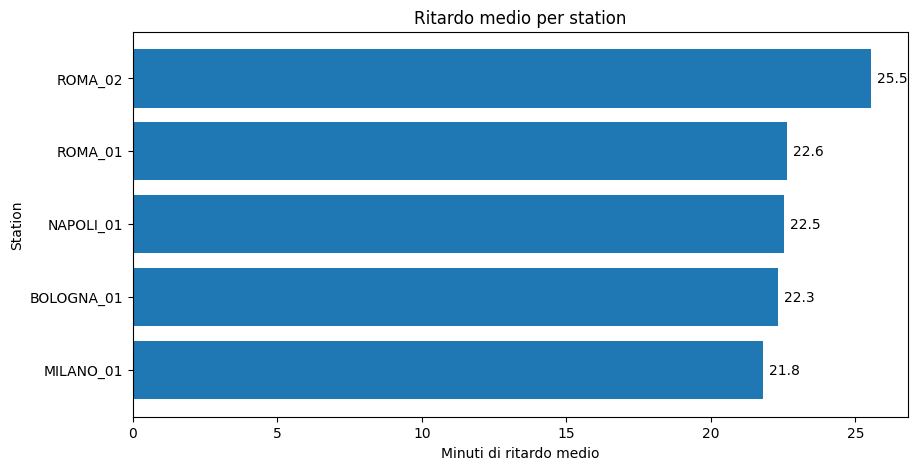

Grafico salvato: C:\Users\manue\Desktop\dashboard_kpi_logistica\report\grafici\ritardo_medio_station.png


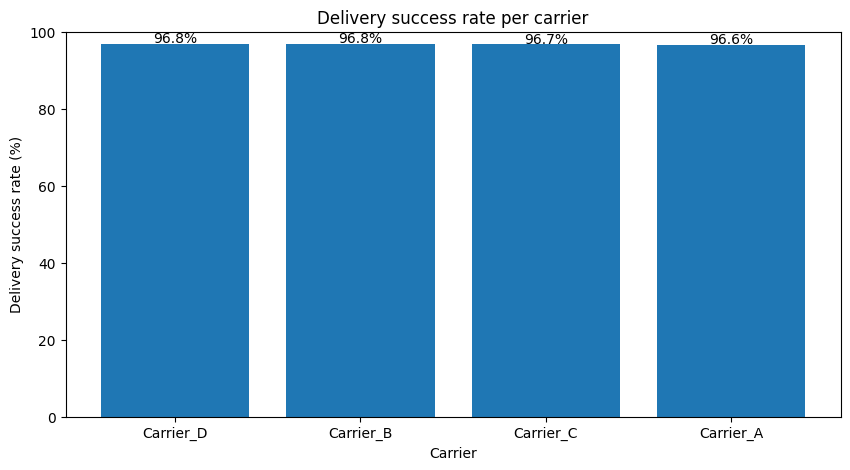

Grafico salvato: C:\Users\manue\Desktop\dashboard_kpi_logistica\report\grafici\success_rate_carrier.png


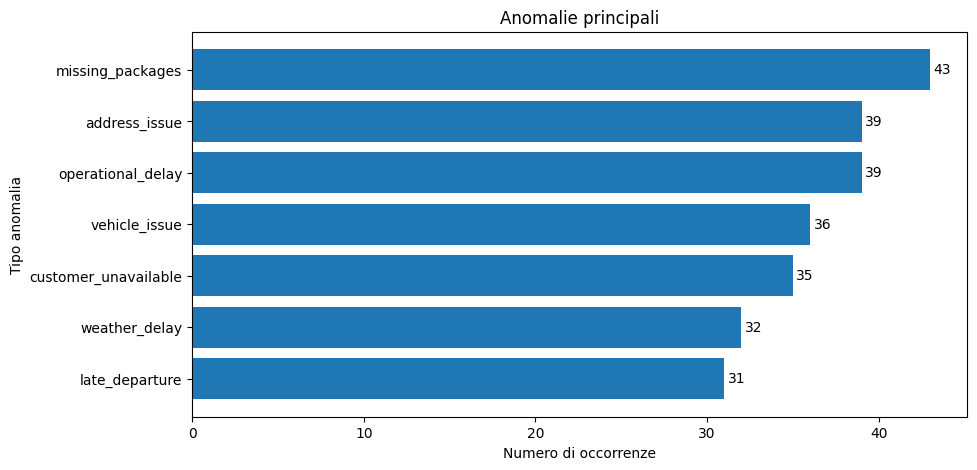

Grafico salvato: C:\Users\manue\Desktop\dashboard_kpi_logistica\report\grafici\anomalie_principali.png


Dashboard HTML creata: C:\Users\manue\Desktop\dashboard_kpi_logistica\report\dashboard_logistica.html


In [1]:

from pathlib import Path
import csv
import subprocess
import sys

try:
    import matplotlib.pyplot as plt
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "matplotlib"])
    import matplotlib.pyplot as plt

from IPython.display import display, HTML


# =========================
# 1. TROVA CARTELLA PROGETTO
# =========================

candidate_dirs = [Path.cwd(), Path.cwd().parent]
BASE_DIR = None

for candidate in candidate_dirs:
    if (candidate / "dati" / "elaborati" / "kpi_generali.csv").exists():
        BASE_DIR = candidate
        break

if BASE_DIR is None:
    raise FileNotFoundError(
        "Non trovo dati/elaborati/kpi_generali.csv. "
        "Controlla di aver aperto Jupyter dalla cartella dashboard_kpi_logistica."
    )

DATI_DIR = BASE_DIR / "dati" / "elaborati"
REPORT_DIR = BASE_DIR / "report"
GRAFICI_DIR = REPORT_DIR / "grafici"

GRAFICI_DIR.mkdir(parents=True, exist_ok=True)

print("Cartella progetto:", BASE_DIR)
print("Cartella dati:", DATI_DIR)
print("Cartella report:", REPORT_DIR)


# =========================
# 2. FUNZIONI DI SUPPORTO
# =========================

def leggi_csv(percorso):
    with open(percorso, mode="r", encoding="utf-8-sig", newline="") as file_csv:
        return list(csv.DictReader(file_csv))


def numero(valore):
    if valore is None:
        return 0

    testo = str(valore).strip().replace(",", ".")

    if testo == "":
        return 0

    return float(testo)


def format_intero(valore):
    return f"{int(round(numero(valore))):,}".replace(",", ".")


def format_decimale(valore, cifre=2):
    return f"{numero(valore):.{cifre}f}".replace(".", ",")


def format_percentuale(valore, cifre=1):
    return f"{numero(valore):.{cifre}f}%".replace(".", ",")


# =========================
# 3. CARICAMENTO KPI
# =========================

file_kpi = {
    "generali": DATI_DIR / "kpi_generali.csv",
    "carrier": DATI_DIR / "kpi_carrier.csv",
    "station": DATI_DIR / "kpi_station.csv",
    "anomalie": DATI_DIR / "kpi_anomalie.csv",
}

dati = {}

for nome, percorso in file_kpi.items():
    if not percorso.exists():
        raise FileNotFoundError(f"File mancante: {percorso}")

    dati[nome] = leggi_csv(percorso)
    print(f"{nome}: {len(dati[nome])} righe lette")

kpi_generali = dati["generali"][0]

display(HTML("""
<div style="padding:12px; border-left:5px solid #2E86AB; background:#f5f9fc; font-family:Arial;">
    <b>Dati caricati correttamente.</b><br>
    I KPI vengono letti dai CSV prodotti dalla pipeline Python.
</div>
"""))


# =========================
# 4. KPI CARD
# =========================

totale_spedizioni = format_intero(kpi_generali["totale_spedizioni"])
delivery_success_rate = format_percentuale(kpi_generali["delivery_success_rate_percent"])
ritardo_medio = format_decimale(kpi_generali["ritardo_medio_minuti"], 2)
pacchi_falliti = format_intero(kpi_generali["totale_pacchi_falliti"])

display(HTML(f"""
<style>
.kpi-grid {{
    display: grid;
    grid-template-columns: repeat(4, 1fr);
    gap: 14px;
    margin: 18px 0 28px 0;
    font-family: Arial, sans-serif;
}}

.kpi-card {{
    border: 1px solid #d9e2ec;
    border-radius: 14px;
    padding: 18px;
    background: #ffffff;
    box-shadow: 0 2px 8px rgba(0,0,0,0.06);
}}

.kpi-label {{
    font-size: 13px;
    color: #52616b;
    margin-bottom: 8px;
}}

.kpi-value {{
    font-size: 30px;
    font-weight: 700;
    color: #102a43;
}}

.kpi-note {{
    font-size: 11px;
    color: #829ab1;
    margin-top: 8px;
}}
</style>

<h1 style="font-family:Arial;">Logistics Operations KPI Dashboard</h1>
<p style="font-family:Arial; color:#52616b;">
Dashboard operativa generata da Python sui dati logistici puliti ed elaborati.
</p>

<div class="kpi-grid">
    <div class="kpi-card">
        <div class="kpi-label">Totale spedizioni</div>
        <div class="kpi-value">{totale_spedizioni}</div>
        <div class="kpi-note">Numero totale di spedizioni analizzate</div>
    </div>

    <div class="kpi-card">
        <div class="kpi-label">Delivery success rate</div>
        <div class="kpi-value">{delivery_success_rate}</div>
        <div class="kpi-note">Percentuale pacchi consegnati correttamente</div>
    </div>

    <div class="kpi-card">
        <div class="kpi-label">Ritardo medio</div>
        <div class="kpi-value">{ritardo_medio} min</div>
        <div class="kpi-note">Ritardo medio sulle spedizioni</div>
    </div>

    <div class="kpi-card">
        <div class="kpi-label">Pacchi falliti</div>
        <div class="kpi-value">{pacchi_falliti}</div>
        <div class="kpi-note">Pacchi non consegnati con successo</div>
    </div>
</div>
"""))


# =========================
# 5. GRAFICO RITARDO PER STATION
# =========================

station = dati["station"]

station_ordinate = sorted(
    station,
    key=lambda riga: numero(riga["ritardo_medio_minuti"]),
    reverse=True
)

nomi_station = [riga["station"] for riga in station_ordinate]
ritardi_station = [numero(riga["ritardo_medio_minuti"]) for riga in station_ordinate]

plt.figure(figsize=(10, 5))
plt.barh(nomi_station, ritardi_station)
plt.gca().invert_yaxis()
plt.title("Ritardo medio per station")
plt.xlabel("Minuti di ritardo medio")
plt.ylabel("Station")

for posizione, valore in enumerate(ritardi_station):
    plt.text(valore + 0.2, posizione, f"{valore:.1f}", va="center")

percorso_grafico_station = GRAFICI_DIR / "ritardo_medio_station.png"
plt.savefig(percorso_grafico_station, dpi=160, bbox_inches="tight")
plt.show()

print("Grafico salvato:", percorso_grafico_station)


# =========================
# 6. GRAFICO SUCCESS RATE PER CARRIER
# =========================

carrier = dati["carrier"]

carrier_ordinati = sorted(
    carrier,
    key=lambda riga: numero(riga["delivery_success_rate_percent"]),
    reverse=True
)

nomi_carrier = [riga["carrier"] for riga in carrier_ordinati]
success_rate_carrier = [numero(riga["delivery_success_rate_percent"]) for riga in carrier_ordinati]

plt.figure(figsize=(10, 5))
plt.bar(nomi_carrier, success_rate_carrier)
plt.title("Delivery success rate per carrier")
plt.xlabel("Carrier")
plt.ylabel("Delivery success rate (%)")
plt.ylim(0, 100)

for posizione, valore in enumerate(success_rate_carrier):
    plt.text(posizione, valore + 0.4, f"{valore:.1f}%", ha="center")

percorso_grafico_carrier = GRAFICI_DIR / "success_rate_carrier.png"
plt.savefig(percorso_grafico_carrier, dpi=160, bbox_inches="tight")
plt.show()

print("Grafico salvato:", percorso_grafico_carrier)


# =========================
# 7. GRAFICO ANOMALIE PRINCIPALI
# =========================

anomalie = [
    riga for riga in dati["anomalie"]
    if riga["exception_type"].strip().lower() != "none"
]

anomalie_ordinate = sorted(
    anomalie,
    key=lambda riga: numero(riga["conteggio"]),
    reverse=True
)

nomi_anomalie = [riga["exception_type"] for riga in anomalie_ordinate]
conteggi_anomalie = [numero(riga["conteggio"]) for riga in anomalie_ordinate]

plt.figure(figsize=(10, 5))
plt.barh(nomi_anomalie, conteggi_anomalie)
plt.gca().invert_yaxis()
plt.title("Anomalie principali")
plt.xlabel("Numero di occorrenze")
plt.ylabel("Tipo anomalia")

for posizione, valore in enumerate(conteggi_anomalie):
    plt.text(valore + 0.2, posizione, str(int(valore)), va="center")

percorso_grafico_anomalie = GRAFICI_DIR / "anomalie_principali.png"
plt.savefig(percorso_grafico_anomalie, dpi=160, bbox_inches="tight")
plt.show()

print("Grafico salvato:", percorso_grafico_anomalie)


# =========================
# 8. GENERAZIONE DASHBOARD HTML
# =========================

dashboard_html_path = REPORT_DIR / "dashboard_logistica.html"

dashboard_html = f"""
<!DOCTYPE html>
<html lang="it">
<head>
    <meta charset="UTF-8">
    <title>Logistics Operations KPI Dashboard</title>

    <style>
        body {{
            font-family: Arial, sans-serif;
            background: #f4f7fb;
            margin: 0;
            padding: 32px;
            color: #102a43;
        }}

        .container {{
            max-width: 1200px;
            margin: auto;
        }}

        .header {{
            margin-bottom: 24px;
        }}

        .header p {{
            color: #52616b;
        }}

        .kpi-grid {{
            display: grid;
            grid-template-columns: repeat(4, 1fr);
            gap: 16px;
            margin-bottom: 28px;
        }}

        .kpi-card {{
            background: white;
            border: 1px solid #d9e2ec;
            border-radius: 16px;
            padding: 20px;
            box-shadow: 0 3px 10px rgba(0,0,0,0.06);
        }}

        .kpi-label {{
            color: #52616b;
            font-size: 13px;
            margin-bottom: 10px;
        }}

        .kpi-value {{
            font-size: 32px;
            font-weight: 700;
        }}

        .section {{
            background: white;
            border: 1px solid #d9e2ec;
            border-radius: 16px;
            padding: 22px;
            margin-bottom: 22px;
            box-shadow: 0 3px 10px rgba(0,0,0,0.06);
        }}

        .section img {{
            width: 100%;
            max-width: 980px;
            display: block;
            margin: auto;
        }}

        .note {{
            font-size: 13px;
            color: #52616b;
            line-height: 1.5;
        }}
    </style>
</head>

<body>
    <div class="container">
        <div class="header">
            <h1>Logistics Operations KPI Dashboard</h1>
            <p>Dashboard generata automaticamente tramite Python a partire dai CSV elaborati.</p>
        </div>

        <div class="kpi-grid">
            <div class="kpi-card">
                <div class="kpi-label">Totale spedizioni</div>
                <div class="kpi-value">{totale_spedizioni}</div>
            </div>

            <div class="kpi-card">
                <div class="kpi-label">Delivery success rate</div>
                <div class="kpi-value">{delivery_success_rate}</div>
            </div>

            <div class="kpi-card">
                <div class="kpi-label">Ritardo medio</div>
                <div class="kpi-value">{ritardo_medio} min</div>
            </div>

            <div class="kpi-card">
                <div class="kpi-label">Pacchi falliti</div>
                <div class="kpi-value">{pacchi_falliti}</div>
            </div>
        </div>

        <div class="section">
            <h2>Ritardo medio per station</h2>
            <p class="note">Confronto tra station in base al ritardo medio operativo.</p>
            <img src="grafici/ritardo_medio_station.png" alt="Ritardo medio per station">
        </div>

        <div class="section">
            <h2>Delivery success rate per carrier</h2>
            <p class="note">Confronto tra carrier in base alla percentuale di pacchi consegnati con successo.</p>
            <img src="grafici/success_rate_carrier.png" alt="Delivery success rate per carrier">
        </div>

        <div class="section">
            <h2>Anomalie principali</h2>
            <p class="note">Distribuzione delle principali anomalie operative, escludendo i casi senza anomalia.</p>
            <img src="grafici/anomalie_principali.png" alt="Anomalie principali">
        </div>
    </div>
</body>
</html>
"""

dashboard_html_path.write_text(dashboard_html, encoding="utf-8")

display(HTML(f"""
<div style="padding:14px; border-left:5px solid #2E7D32; background:#f1f8f4; font-family:Arial;">
    <b>Dashboard HTML generata correttamente.</b><br>
    File creato in:<br>
    <code>{dashboard_html_path}</code>
</div>
"""))

print("Dashboard HTML creata:", dashboard_html_path)
